# Quick test: visualize volumes, masks, and a tiny reconstruction demo

This notebook is meant to be a **minimal, executable** sanity-check for:

1. Converting a `.tif` to a downsampled `.npy` volume
2. Visualizing the `.npy` volume slices (via `draw_nifti_slices_with_quiver`)
3. Creating a masked pretext sample and visualizing input/target/mask
4. Running a tiny `FishModule` forward pass to see reconstruction inside the mask

In [30]:
# --- Parameters (edit these first) ---
from pathlib import Path

# Input/Output paths

# Directory containing one or more .tif/.tiff files
tif_dir = Path("data/raw/quick_test")

# Downsample scale_factor (D, H, W) passed to tif2volume
# scale = (1.0, 1.0, 1.0)
# scale = (0.25, 0.25, 0.25)
scale = (0.0625, 0.0625, 0.0625)

npy_dir = Path(f"data/volume/downsample/quick_test_{scale[0]}")

# Mask parameters (used by pretext dataset generator)
mask_type = "block"  # 'block' or 'patch'
mask_ratio = 0.3

# Where train.pt / val.pt will be written
pt_dir = Path(f"data/formalpt/downsample/quick_test_{scale[0]}_{mask_type}_{mask_ratio:02f}")

# Config for lightining module + logging
cfg_path = Path("config/quick_test.yaml")
# Train params for quick sanity runs
max_epochs = 50
batch_size = 2
num_workers = 0

In [14]:
# --- Imports ---
import numpy as np
import torch

from utils.tif2volume import batch_process_tifs
from utils.gen_pretext_dataset import create_masked_sample, split_dataset
from utils.visualize_3d_slice import draw_nifti_slices_with_quiver, draw_nifti_slices_with_gt

from utils.load_config import load_config
from model.lightning.fish_module import FishModule, create_dataloaders

import pytorch_lightning as L
from pytorch_lightning.loggers import TensorBoardLogger

%matplotlib widget
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1) Convert TIF → NPY (using `utils/tif2volume.py`), preprocess

In [19]:
# Convert all .tif/.tiff in tif_dir -> ONE batched .npy (N,C,D,H,W) (safe to re-run)
assert tif_dir.exists(), f"Missing dir: {tif_dir}"
npy_dir.mkdir(parents=True, exist_ok=True)

batch_process_tifs(tif_dir, npy_dir, scale_factor=scale, normalize=True, mode="downsample")

Loading data\raw\quick_test\3dpf_0601_FLUO4_10_ShiftCorrectionAuto.tif...
Original shape: (435, 3116, 658), dtype: uint16
Downsampled shape: (28, 195, 42)
Loading data\raw\quick_test\3dpf_0601_FLUO4_1_ShiftCorrectionAuto.tif...
Original shape: (446, 3167, 658), dtype: uint16
Downsampled shape: (28, 198, 42)
Loading data\raw\quick_test\3dpf_0601_FLUO8_10_ShiftCorrectionAuto.tif...
Original shape: (434, 3114, 658), dtype: uint16
Downsampled shape: (28, 195, 42)
Loading data\raw\quick_test\3dpf_0601_FLUO8_11_ShiftCorrectionAuto.tif...
Original shape: (435, 3106, 658), dtype: uint16
Downsampled shape: (28, 195, 42)
Loading data\raw\quick_test\4dpf_0601_FLUO12_3_ShiftCorrectionAuto.tif...
Original shape: (375, 2880, 658), dtype: uint16
Downsampled shape: (24, 180, 42)
Loading data\raw\quick_test\4dpf_0601_FLUO1_4_ShiftCorrectionAuto.tif...
Original shape: (429, 3099, 658), dtype: uint16
Downsampled shape: (27, 194, 42)
Loading data\raw\quick_test\5dpf_0601_FLUO1_20_ShiftCorrectionAuto.tif..

'data\\volume\\downsample\\quick_test_0.0625'

Loaded: data\volume\downsample\quick_test_0.0625\3dpf_0601_FLUO4_10_ShiftCorrectionAuto_down_(24, 180, 42).npy
batched shape: (1, 1, 24, 180, 42) dtype: float32 range: (0.0, 1.0)


interactive(children=(IntSlider(value=0, description='Time', max=0), IntSlider(value=20, description='Slice Z'…

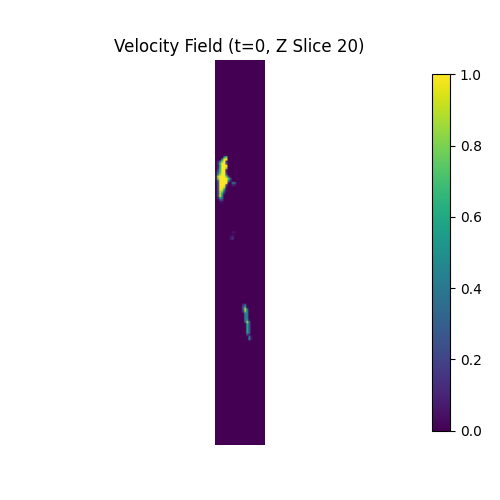

In [24]:
# Load ONE item from the batched file for visualization
batched_npy_path = list(npy_dir.glob("*.npy"))
batched = np.load(batched_npy_path[3])  # (N,C,D,H,W)
print("Loaded:", batched_npy_path[0])
print("batched shape:", batched.shape, "dtype:", batched.dtype, "range:", (float(batched.min()), float(batched.max())))

raw = batched[0, 0]  # (D,H,W)
assert raw.ndim == 3, f"Unexpected item shape: {raw.shape}"
_ = draw_nifti_slices_with_quiver(raw, slice_along_axis='z')

In [ ]:
# experimental: try other preprocess or cleaning to npy data.
# from utils.deskew import deskew_volume_xy
# x_skew_ratio = 0.62 * vol3d.shape[1] / vol3d.shape[0]
# deskew_vol3d = deskew_volume_xy(vol3d, x_skew_ratio=x_skew_ratio)
# print("deskewed shape:", deskew_vol3d.shape, "range:", (float(deskew_vol3d.min()), float(deskew_vol3d.max())))
# _ = draw_nifti_slices_with_quiver(deskew_vol3d, slice_along_axis='z')

## 2) Create a masked pretext sample & visualize input/target/mask

input: (1, 24, 180, 42) target: (1, 24, 180, 42) mask: (1, 24, 180, 42)
mask unique: tensor([0., 1.])


interactive(children=(IntSlider(value=0, description='Time', max=0), IntSlider(value=20, description='Slice Z'…

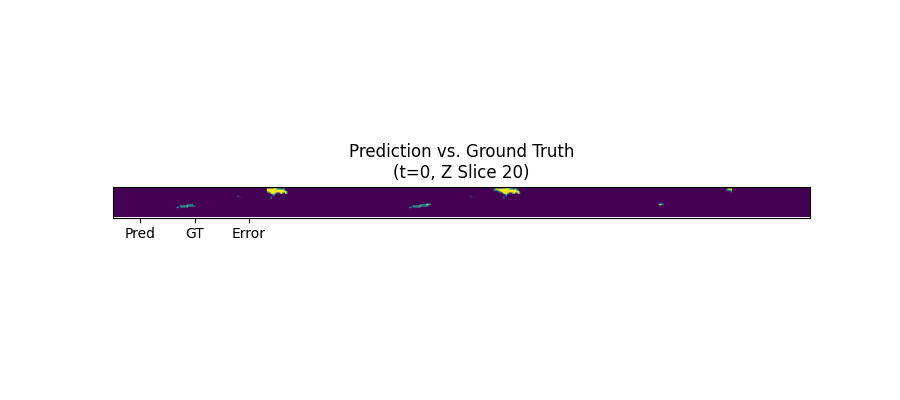

In [25]:
# experimental: try other way to mask data.

sample = create_masked_sample(
    raw,
    mask_type=mask_type,
    mask_ratio=mask_ratio,
    block_size_range=(8, 32),
    patch_size=2,
 )

inp = sample["input"]  # (C,D,H,W)
tgt = sample["target"] # (C,D,H,W)
msk = sample["mask"]   # (1,D,H,W)

print("input:", tuple(inp.shape), "target:", tuple(tgt.shape), "mask:", tuple(msk.shape))
print("mask unique:", torch.unique(msk))

# Visualize: use channel 0
inp3d = inp[0]
tgt3d = tgt[0]
msk3d = msk[0] # mask 0 means hidden area.
draw_nifti_slices_with_gt(inp3d.unsqueeze(-1), tgt3d.unsqueeze(-1), 
                          slice_along_axis="z")


In [31]:
cfg = load_config("config/quick_test.yaml")

# Generate train.pt / val.pt from the converted volumes, then train
pt_dir.mkdir(parents=True, exist_ok=True)

split_dataset(
    volume_dir=str(npy_dir),
    output_dir=str(pt_dir),
    train_ratio=0.8,
    samples_per_volume=5,
    mask_type=mask_type,
    mask_ratio=mask_ratio,
    seed=cfg['seed'],
    patch_size=4,
 )

train_pt = pt_dir / "train.pt"
val_pt = pt_dir / "val.pt" if (pt_dir / "val.pt").exists() else None
print("train:", train_pt)
print("val  :", val_pt, "exists:", (val_pt.exists() if val_pt else False))

dls = create_dataloaders(
    train_path=str(train_pt),
    val_path=(str(val_pt) if val_pt else None),
    batch_size=batch_size,
    num_workers=num_workers,
 )

Found 11 volume files
Train: 8 volumes, Val: 3 volumes
Generating pretext dataset from 8 volumes...


100%|██████████| 8/8 [00:00<00:00, 241.21it/s]


Saved dataset with 40 samples to data\formalpt\downsample\quick_test_0.0625_block_0.300000\train.pt
Generating pretext dataset from 3 volumes...


100%|██████████| 3/3 [00:00<00:00, 252.26it/s]

Saved dataset with 15 samples to data\formalpt\downsample\quick_test_0.0625_block_0.300000\val.pt
Dataset generation complete!
train: data\formalpt\downsample\quick_test_0.0625_block_0.300000\train.pt
val  : data\formalpt\downsample\quick_test_0.0625_block_0.300000\val.pt exists: True


## 3) build a tiny `FishModule` and train on pretext task

In [27]:
# Keep this notebook minimal: we only need model + training kwargs for FishModule init.
model_kwargs = dict(cfg["model"])
train_kwargs = dict(cfg["training"])

# Override to a small model so it runs fast in-notebook
module = FishModule(**{**model_kwargs, **train_kwargs})
print("Tiny model params:", module.model.get_num_params())

Tiny model params: 294561


In [ ]:
logging_kwargs = dict(cfg.get("logging", {}))
# TensorBoard logger: uses config logging.experiment_name
experiment_name = logging_kwargs.get("experiment_name", "quick_test")
logger = TensorBoardLogger(name=experiment_name)
print("TensorBoard log dir:", logger.log_dir)

# Train with TensorBoard logging
trainer = L.Trainer(
    max_epochs=max_epochs,
    log_every_n_steps=1,
    enable_checkpointing=False,
    logger=logger,
 )

trainer.fit(module, train_dataloaders=dls["train"], val_dataloaders=dls.get("val"))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores

  | Name      | Type    | Params | Mode  | FLOPs
------------------------------------------------------
0 | model     | UNet3D  | 294 K  | train | 0    
1 | criterion | MSELoss | 0      | train | 0    
------------------------------------------------------
294 K     Trainable params
0         Non-trainable params
294 K     Total params
1.178     Total estimated model params size (MB)
46        Modules in train mode
0         Modules in eval mode
0         Total Flops


TensorBoard log dir: results\quick_test/unet\version_1


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


## 5) Infer one sample and visualize reconstruction vs target (focus on masked region)

In [ ]:
# Infer one batch and visualize reconstruction vs target (focus on masked region)
module.eval()

batch = next(iter(dls["train"]))
x = batch["input"]   # (B,C,D,H,W)
y = batch["target"]  # (B,C,D,H,W)
m = batch["mask"]    # (B,1,D,H,W)

with torch.no_grad():
    pred = module(x)  # (B,C,D,H,W)

# Visualize first item, channel 0
pred3d = pred[0, 0].detach().cpu()
tgt3d = y[0, 0].detach().cpu()
msk3d = m[0, 0].detach().cpu()

draw_nifti_slices_with_gt(pred3d.unsqueeze(-1), tgt3d.unsqueeze(-1))